In [2]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv("lyon_buildings.csv")


C:\Users\USER\AppData\Local\Temp\ipykernel_6368\1177532594.py:1: DtypeWarning: Columns (7,25,50,173,174,175,176) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lyon_buildings.csv")


In [10]:
df.head()

,numero_dpe,date_derniere_modification_dpe,date_visite_diagnostiqueur,date_etablissement_dpe,date_reception_dpe,date_fin_validite_dpe,numero_dpe_remplace,numero_dpe_immeuble_associe,id_rnb,numero_rpls_logement,...,description_generateur_froid,surface_climatisee,conso_refroidissement_annuel,categorie_enr,systeme_production_electricite_origine_renouvelable,presence_production_pv,surface_totale_capteurs_pv,nombre_module,production_electricite_pv_kwhep_par_an,electricite_pv_autoconsommee
0,2269E1193349T,2024-12-30,2022-05-30,2022-05-30,2022-05-31,2032-05-29,NaN,NaN,Y3HW4DCK8J7G,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2269E1229188E,2024-06-25,2022-05-23,2022-05-23,2022-06-03,2032-05-22,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2269E0225452Y,2024-12-30,2022-02-02,2022-02-02,2022-02-04,2032-02-01,NaN,NaN,K6GXV31FBN28,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,2269E0364316W,2024-02-06,2021-08-29,2022-02-22,2022-02-23,2032-02-21,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2269E0040146U,2024-12-30,2021-12-23,2022-01-09,2022-01-10,2032-01-08,NaN,NaN,81EYZBD4TY84,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [11]:
print(df.columns.tolist())

['numero_dpe', 'date_derniere_modification_dpe', 'date_visite_diagnostiqueur', 'date_etablissement_dpe', 'date_reception_dpe', 'date_fin_validite_dpe', 'numero_dpe_remplace', 'numero_dpe_immeuble_associe', 'id_rnb', 'numero_rpls_logement', 'numero_immatriculation_copropriete', 'modele_dpe', 'version_dpe', 'methode_application_dpe', 'etiquette_dpe', 'etiquette_ges', 'type_batiment', 'annee_construction', 'periode_construction', 'type_installation_chauffage', 'type_installation_ecs', 'hauteur_sous_plafond', 'nombre_appartement', 'nombre_niveau_immeuble', 'nombre_niveau_logement', 'typologie_logement', 'appartement_non_visite', 'surface_habitable_immeuble', 'surface_habitable_logement', 'surface_tertiaire_immeuble', 'classe_inertie_batiment', 'classe_altitude', 'zone_climatique', 'adresse_ban', 'numero_voie_ban', 'nom_rue_ban', 'nom_commune_ban', 'code_postal_ban', 'code_insee_ban', 'code_departement_ban', 'code_region_ban', 'identifiant_ban', 'coordonnee_cartographique_x_ban', 'coordonne

In [12]:
from pyproj import Transformer

def convert_coordinates(df):
    transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(df["coordonnee_cartographique_x_ban"].values,
                                     df["coordonnee_cartographique_y_ban"].values)
    df["longitude"] = lon
    df["latitude"] = lat
    return df


In [13]:
df = convert_coordinates(df)
df = df.rename(columns={
    "numero_dpe": "building_id",
    "conso_5 usages_ef": "Energy_Consumption",
    "emission_ges_5_usages": "CO2_Usage"
})

df["Water_Usage"] = df["Energy_Consumption"] * 0.3  

df["Energy_Intensity"] = df["conso_5 usages_par_m2_ef"]
df["CO2_Intensity"] = df["emission_ges_5_usages par_m2"]

final_cols = [
    "building_id", "latitude", "longitude",
    "Energy_Consumption", "CO2_Usage", "Water_Usage",
    "Energy_Intensity", "CO2_Intensity"
]

df = df[final_cols].dropna()

In [14]:


# Save as clean dataset
df.to_csv("reduced_lyon_buildings.csv", index=False)

print(" Clean dataset saved.")


 Clean dataset saved.


===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   building_id         374 non-null    object 
 1   latitude            374 non-null    float64
 2   longitude           374 non-null    float64
 3   Energy_Consumption  374 non-null    float64
 4   CO2_Usage           374 non-null    float64
 5   Water_Usage         374 non-null    float64
 6   Energy_Intensity    374 non-null    float64
 7   CO2_Intensity       374 non-null    float64
dtypes: float64(7), object(1)
memory usage: 23.5+ KB

===== MISSING VALUES =====
building_id           0
latitude              0
longitude             0
Energy_Consumption    0
CO2_Usage             0
Water_Usage           0
Energy_Intensity      0
CO2_Intensity         0
dtype: int64

===== DESCRIPTIVE STATISTICS =====
                    count          mean           std         

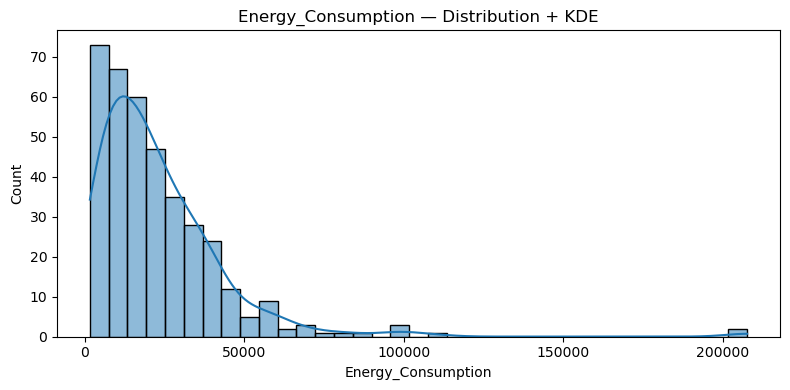

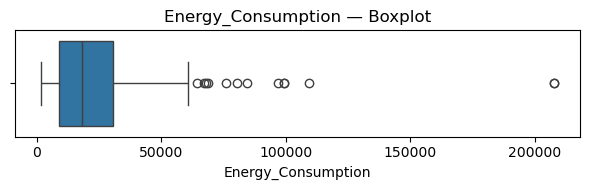

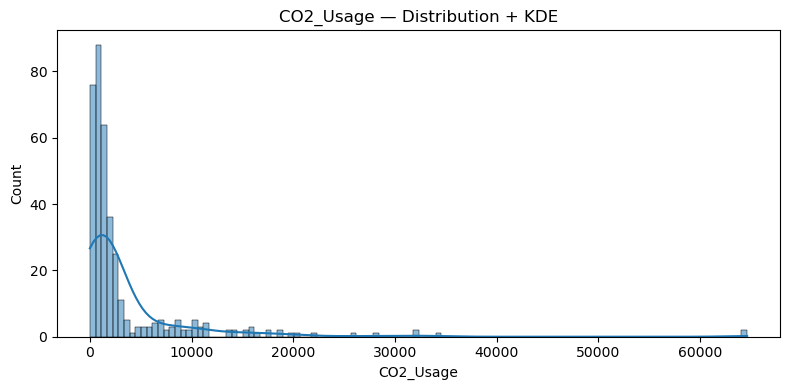

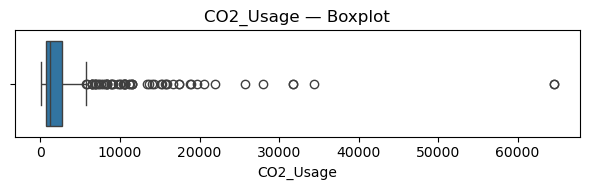

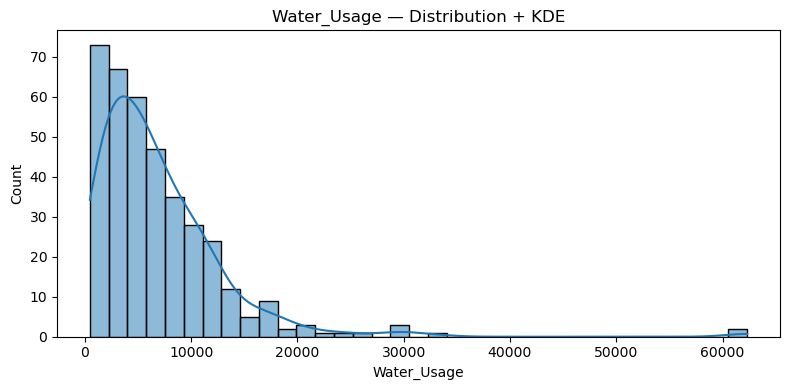

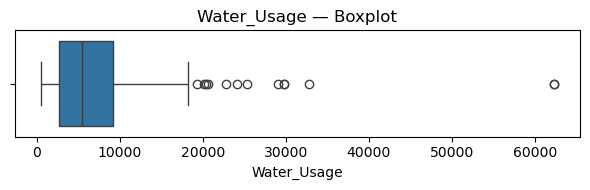

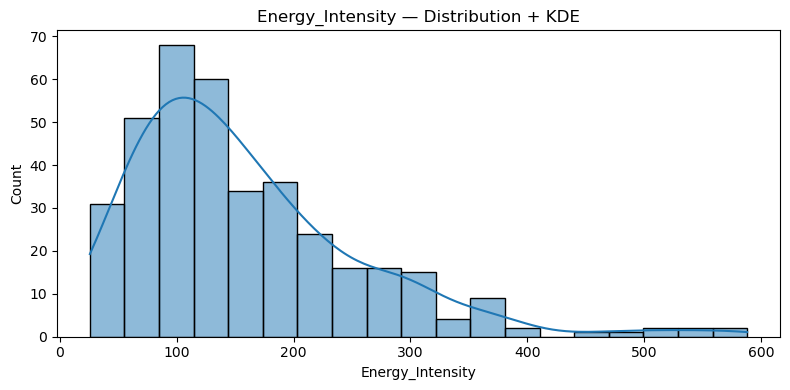

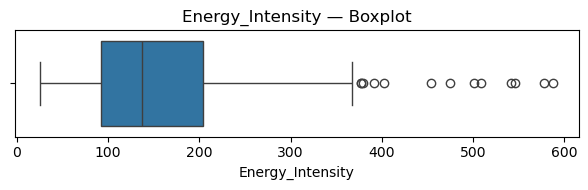

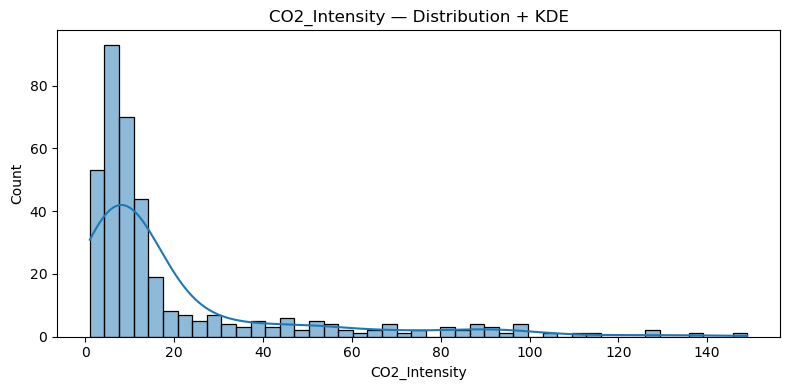

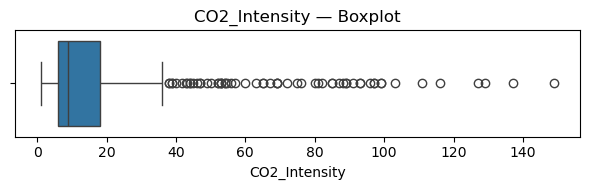


===== CORRELATION MATRIX =====
                    Energy_Consumption  CO2_Usage  Water_Usage  \
Energy_Consumption            1.000000   0.906948     1.000000   
CO2_Usage                     0.906948   1.000000     0.906948   
Water_Usage                   1.000000   0.906948     1.000000   
Energy_Intensity              0.471044   0.397360     0.471044   
CO2_Intensity                 0.602196   0.727863     0.602196   

                    Energy_Intensity  CO2_Intensity  
Energy_Consumption          0.471044       0.602196  
CO2_Usage                   0.397360       0.727863  
Water_Usage                 0.471044       0.602196  
Energy_Intensity            1.000000       0.699056  
CO2_Intensity               0.699056       1.000000  


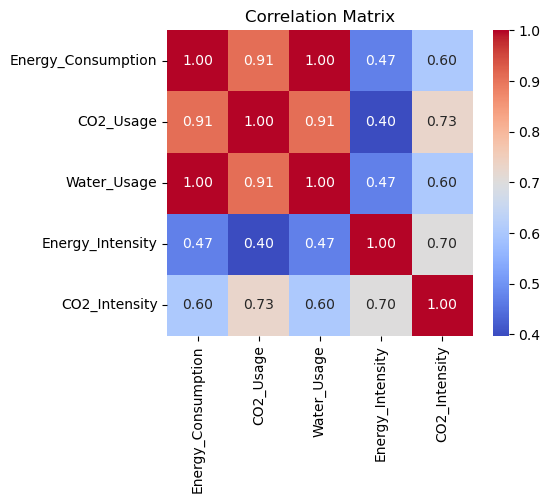

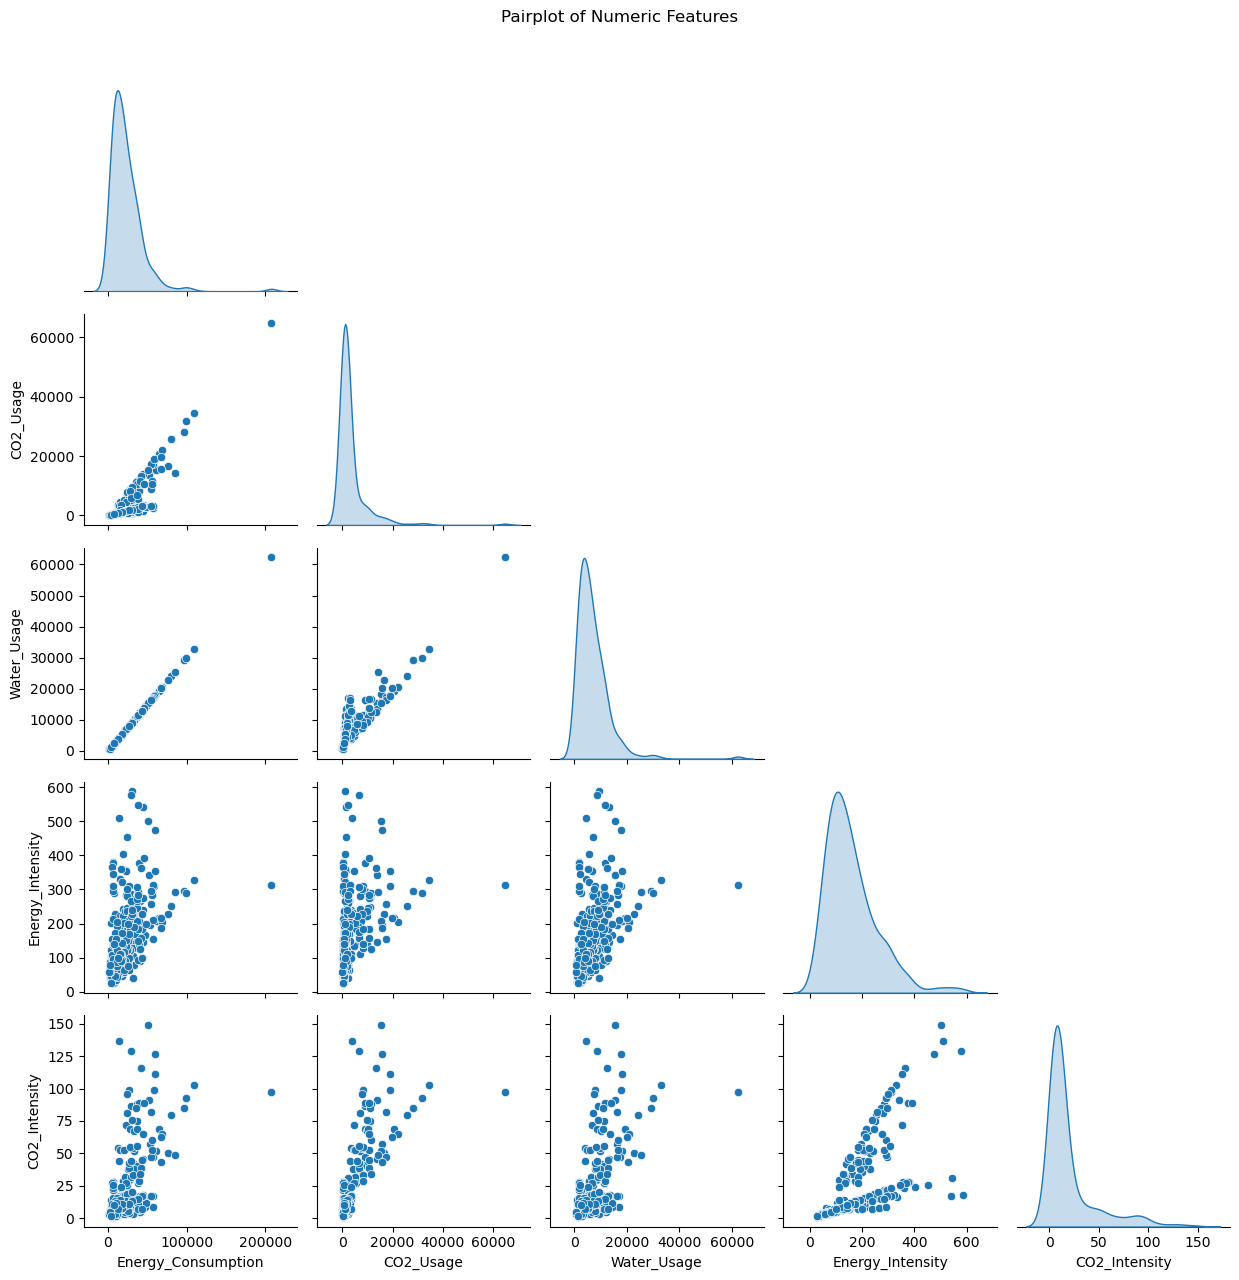

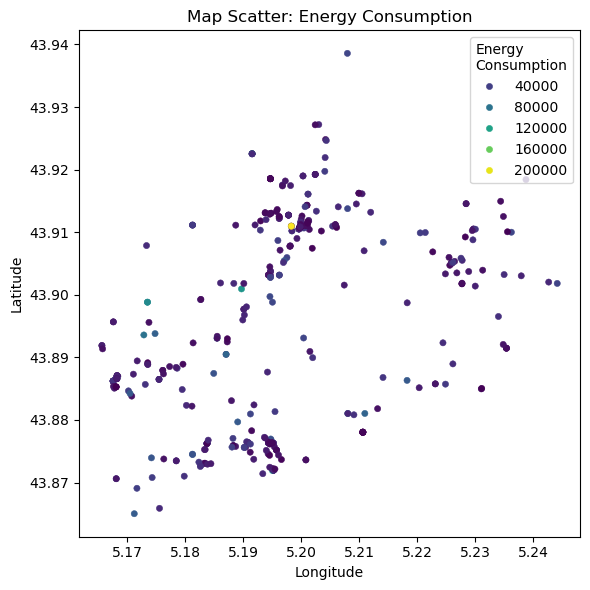

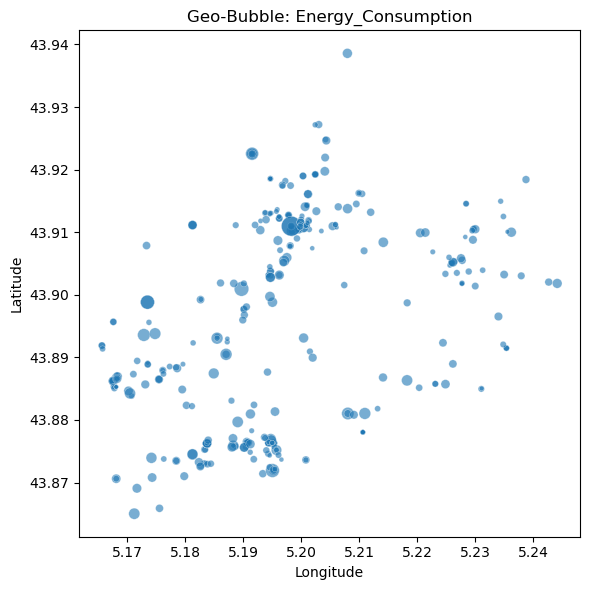

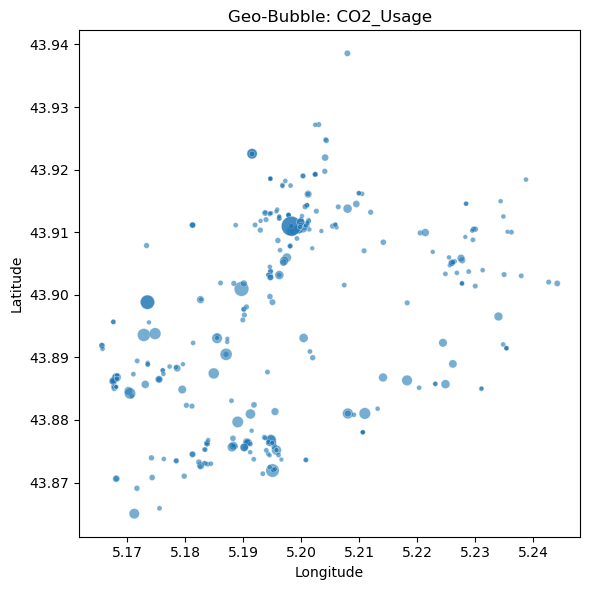

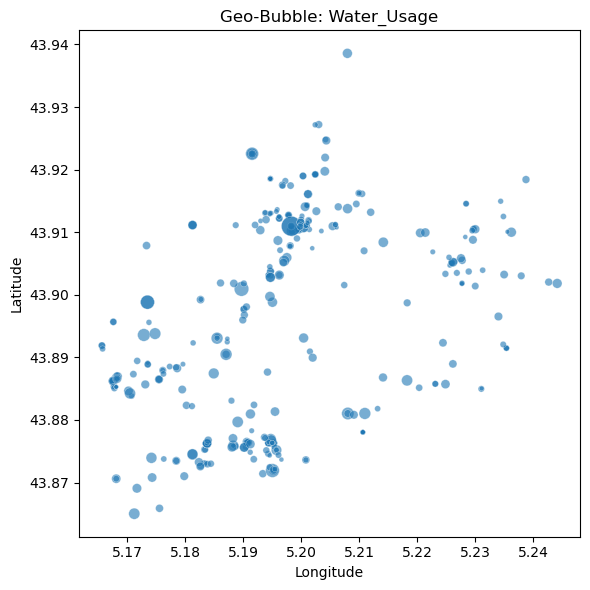

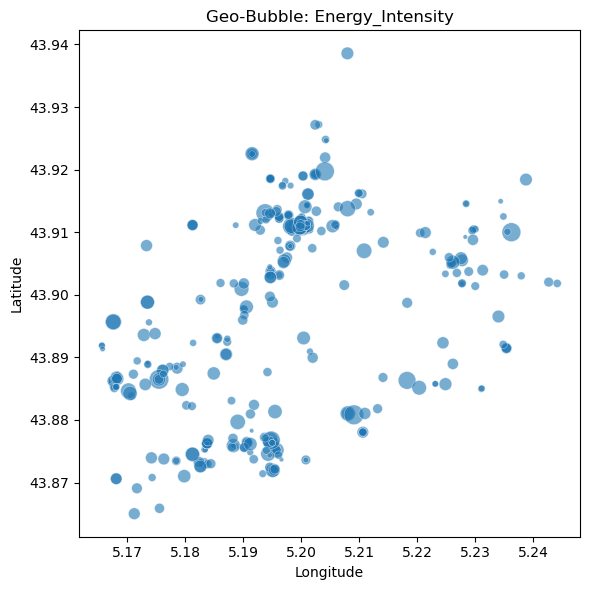

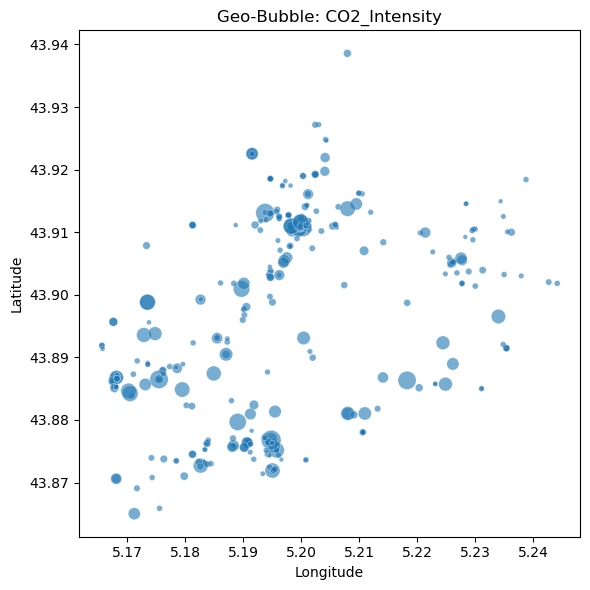

In [8]:
# eda_buildings_inline.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If you’re in a Jupyter notebook, enable inline plotting:
# %matplotlib inline

# 1. Load the data
df = pd.read_csv("reduced_gordes_buildings.csv")

# 2. Quick overview
print("===== DATA INFO =====")
df.info()
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe().T)

# Identify numeric features (exclude ID & coords)
numeric_cols = [
    "Energy_Consumption",
    "CO2_Usage",
    "Water_Usage",
    "Energy_Intensity",
    "CO2_Intensity"
]

# 3. Univariate distributions
for col in numeric_cols:
    # Distribution + KDE
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} — Distribution + KDE")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Boxplot")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# 4. Correlation matrix
corr = df[numeric_cols].corr()
print("\n===== CORRELATION MATRIX =====")
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 5. Pairwise scatterplots
sns.pairplot(df[numeric_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# 6. Geographic scatter (colored by Energy_Consumption)
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df["longitude"], y=df["latitude"],
    hue=df["Energy_Consumption"],
    palette="viridis", edgecolor=None, s=20
)
plt.title("Map Scatter: Energy Consumption")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Energy\nConsumption", loc="upper right")
plt.tight_layout()
plt.show()

# 7. Geographic bubble plots (sized by each feature)
for col in numeric_cols:
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        x=df["longitude"], y=df["latitude"],
        size=df[col], sizes=(10,200), alpha=0.6, legend=False
    )
    plt.title(f"Geo‑Bubble: {col}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


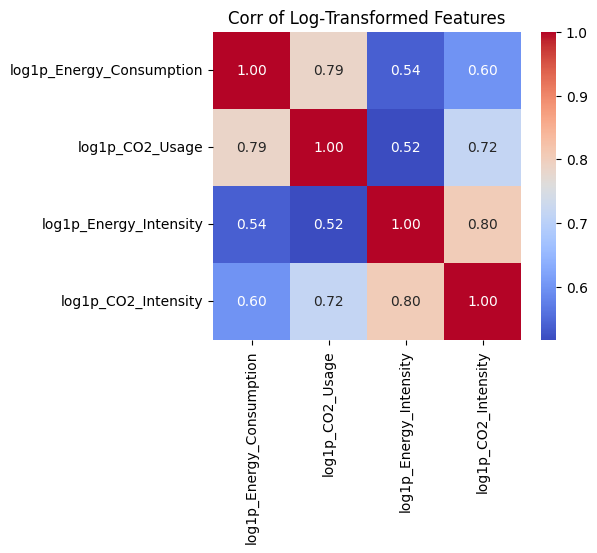

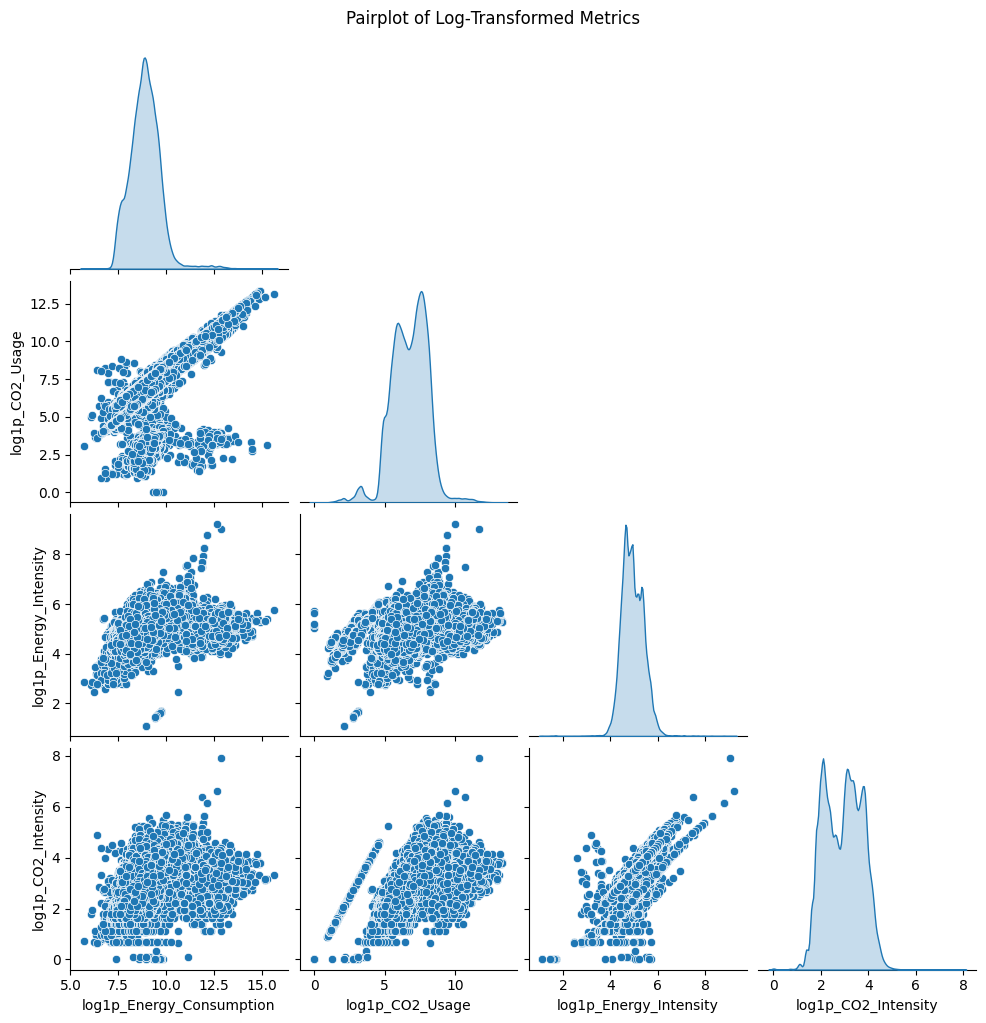

Explained variance ratios: [0.74591729 0.15757186]


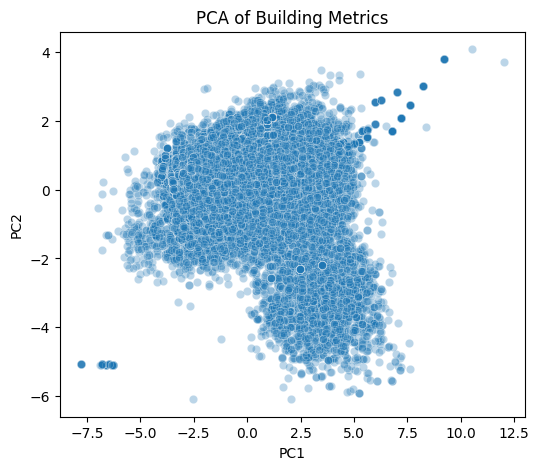

c:\Users\ZBooK\Desktop\Building_Scoring\.conda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ZBooK\Desktop\Building_Scoring\.conda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ZBooK\Desktop\Building_Scoring\.conda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ZBooK\Desktop\Building_Scoring\.conda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ZBooK\Desktop\Bui

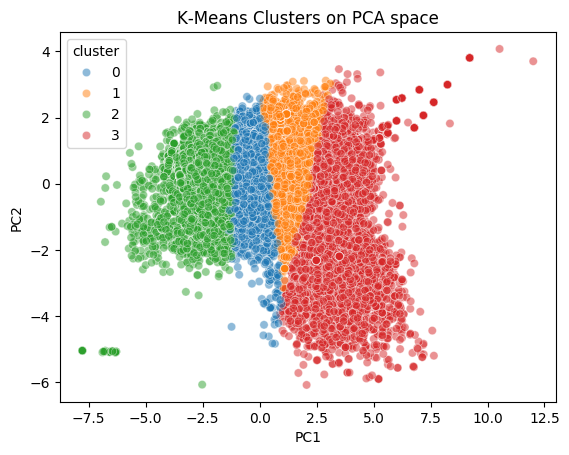

In [4]:
import numpy as np
import pandas as pd

# assume df is your DataFrame from before
df2 = df.drop(columns=["Water_Usage"]).copy()

# Choose which columns to log‐transform
to_log = ["Energy_Consumption", "CO2_Usage", "Energy_Intensity", "CO2_Intensity"]

for col in to_log:
    df2[f"log1p_{col}"] = np.log1p(df2[col])
import seaborn as sns
import matplotlib.pyplot as plt

log_cols = [f"log1p_{c}" for c in to_log]
corr2 = df2[log_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Corr of Log‑Transformed Features")
plt.show()
sns.pairplot(df2[log_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Log‑Transformed Metrics", y=1.02)
plt.show()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df2[log_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)

# attach back to df2 for plotting
df2["PC1"], df2["PC2"] = pcs[:,0], pcs[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1", y="PC2", data=df2, alpha=0.3)
plt.title("PCA of Building Metrics")
plt.show()

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df2["cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x="PC1", y="PC2", hue="cluster", data=df2, palette="tab10", alpha=0.5)
plt.title("K‑Means Clusters on PCA space")
plt.show()


In [ ]:
selected_columns = [
    "numero_dpe",                       # building ID
    "nom_commune_ban", "code_postal_ban",
    "coordonnee_cartographique_x_ban", "coordonnee_cartographique_y_ban",

    "surface_habitable_logement",      # geometry
    "hauteur_sous_plafond",
    "annee_construction",
    "nombre_appartement", "nombre_niveau_immeuble",

    "conso_5 usages_ef",               # energy usage (core)
    "emission_ges_5_usages",           # emissions (core)
    "conso_chauffage_ef", "conso_ecs_ef", "conso_refroidissement_ef",
    "conso_eclairage_ef", "conso_auxiliaires_ef",

    "conso_5 usages_par_m2_ef",        # energy per area
    "emission_ges_5_usages par_m2",    # emissions per area

    "besoin_chauffage", "besoin_ecs", "besoin_refroidissement",

    "ubat_w_par_m2_k",                 # envelope efficiency

    "type_energie_n1", "type_energie_n2", "type_energie_n3",
    "type_energie_principale_chauffage", "type_energie_principale_ecs"
]
